In natural language processing and machine learning Naive Bayes is a popular method for classifying text documents. It can be used to classifies documents into pre defined types based on likelihood of a word occurring by using Bayes theorem. In this article we will implement Text Classification using Naive Bayes in Python

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [38]:
data = pd.read_csv('./synthetic_text_data.csv')
X = data['text']
y = data['label']

print(X , end='\n\n')
print(y , end='\n\n')

0     Artificial intelligence is advancing in health...
1     Football fans are excited about the upcoming W...
2     New policies regarding climate change have spa...
3     The latest blockbuster movie has shattered box...
4     Quantum computing promises to revolutionize in...
                            ...                        
80    AI is enhancing customer experiences in retail...
81    Politicians are debating the pros and cons of ...
82    Television networks are trying to adapt to the...
83    New wearable technologies are improving health...
84    Local sports leagues are organizing tournament...
Name: text, Length: 85, dtype: str

0        Technology
1            Sports
2          Politics
3     Entertainment
4        Technology
          ...      
80       Technology
81         Politics
82    Entertainment
83       Technology
84           Sports
Name: label, Length: 85, dtype: str



In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### text preprocessing: converting Text to Numeric Features.
### we use CountVectorizer to convert the text into a matrix of token counts.

In [40]:

# CountVectorizer(): Converts the raw text into a matrix of word counts.
vectorizer = CountVectorizer()

# fit_transform(): Learns the vocabulary from the training data and transforms the text into vector.
X_train_Vectorized = vectorizer.fit_transform(X_train)

# transform(): Applies the learned vocabulary from the training data to the test data.
X_test_Vectorized = vectorizer.transform(X_test)

print(X_train_Vectorized, end='\n\n')
print('#'*60)
print(X_train, end='\n\n')
print('#'*60)
print(X_test_Vectorized, end='\n\n')
print('#'*60)
print(X_test)
print('#'*60)
print(f"Features (X) shape: {X_train_Vectorized}")
print(f"Labels (y) shape: {y_train}")

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 787 stored elements and shape (68, 395)>
  Coords	Values
  (0, 96)	1
  (0, 85)	1
  (0, 13)	1
  (0, 41)	1
  (0, 344)	1
  (0, 18)	1
  (0, 294)	1
  (0, 136)	1
  (1, 13)	2
  (1, 18)	1
  (1, 298)	1
  (1, 103)	1
  (1, 36)	1
  (1, 230)	1
  (1, 61)	1
  (1, 179)	1
  (1, 183)	1
  (1, 332)	1
  (1, 23)	1
  (1, 215)	1
  (1, 95)	1
  (2, 179)	1
  (2, 347)	1
  (2, 341)	1
  (2, 184)	1
  :	:
  (66, 347)	2
  (66, 141)	1
  (66, 392)	1
  (66, 130)	1
  (66, 206)	1
  (66, 21)	1
  (66, 356)	1
  (66, 133)	1
  (66, 380)	1
  (66, 12)	1
  (66, 368)	1
  (66, 123)	1
  (66, 319)	1
  (67, 18)	1
  (67, 347)	1
  (67, 351)	1
  (67, 304)	2
  (67, 340)	1
  (67, 141)	1
  (67, 237)	1
  (67, 140)	1
  (67, 256)	1
  (67, 266)	1
  (67, 142)	1
  (67, 267)	1

############################################################
77    Digital currencies and blockchain technology a...
42    Robots and drones are becoming more common in ...
49    The tech industry is seeing increase

In [41]:
model = MultinomialNB()
model.fit(X_train_Vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [42]:
y_pred = model.predict(X_test_Vectorized)

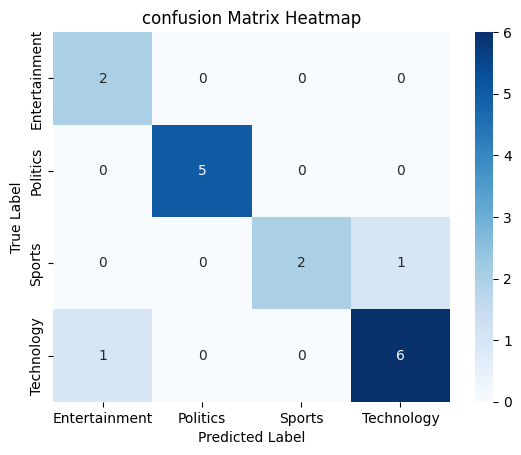

In [44]:
acuuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

f"Accuracy: {acuuracy * 100}%"

class_labels = np.unique(y_test)

plt.Figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d',
            cmap='Blues',xticklabels=class_labels,
            yticklabels=class_labels )
plt.title('confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [45]:
user_input = ("i love training with artificial intelligence applications")

user_input_vectorized = vectorizer.transform([user_input])

predicted_label = model.predict(user_input_vectorized)

print(f"the input text belongs to the '{predicted_label[0]}' category.")

the input text belongs to the 'Technology' category.
